<a href="https://colab.research.google.com/github/yoradzasky/2025-AI-TI1B/blob/main/UTS_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [38]:
df_airbnb = pd.read_csv('./airbnb.csv')
df_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Check Data Info

In [39]:
df.info()              # Tipe data & jumlah non-null



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   listing_name                    48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   neighbourhood_group             48895 non-null  object 
 4   neighbourhood                   48895 non-null  object 
 5   latitude                        48895 non-null  float64
 6   longitude                       48895 non-null  float64
 7   room_type                       48895 non-null  object 
 8   price                           48895 non-null  int64  
 9   minimum_nights                  48895 non-null  int64  
 10  number_of_reviews               48895 non-null  int64  
 11  last_review                     38843 non-null  object 
 12  reviews_per_month               

---

## 1. Pandas: Read, Series, DataFrame, Manipulation, Plotting

### 1.1 Read

In [66]:
df_airbnb = pd.read_csv('./airbnb.csv')
df_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [55]:
# Total properti yang tersedia di dataset
total_properti = len(df)
print("Total properti di dataset Airbnb:", total_properti)


Total properti di dataset Airbnb: 48895


In [40]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,total_potential_revenue
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000,4.889500e+04
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327,1.981057e+04
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289,5.900602e+04
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000e+00
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000,0.000000e+00
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000,4.293000e+03
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000,2.251500e+04
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000,3.649635e+06


In [41]:
df.columns

Index(['id', 'listing_name', 'host_id', 'neighbourhood_group', 'neighbourhood',
       'latitude', 'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'total_potential_revenue'],
      dtype='object')

### 1.2 Series

In [42]:
df['price']            # Series: 1 kolom

,price,room_type
0,149,Private room
1,225,Entire home/apt
2,150,Private room
3,89,Entire home/apt
4,80,Entire home/apt
...,...,...
48890,70,Private room
48891,40,Private room
48892,115,Entire home/apt
48893,55,Shared room


### 1.3 Data Frame

In [67]:
df[['price', 'room_type']]  # DataFrame: 2 kolom

,price,room_type
0,149,Private room
1,225,Entire home/apt
2,150,Private room
3,89,Entire home/apt
4,80,Entire home/apt
...,...,...
48890,70,Private room
48891,40,Private room
48892,115,Entire home/apt
48893,55,Shared room


### 1.4 Manipulation

In [77]:
# Salin ulang DataFrame
df_cleaned = df.copy()

# 1. Hapus baris yang memiliki nilai kosong pada kolom 'name'
df_cleaned.dropna(subset=['listing_name'], inplace=True)

# 2. Mengisi nilai kosong dengan assignment langsung
df_cleaned['reviews_per_month'] = df_cleaned['reviews_per_month'].fillna(0)
df_cleaned['last_review'] = df_cleaned['last_review'].fillna('Unknown')

# 3. Menghapus outlier
df_cleaned = df_cleaned[(df_cleaned['price'] > 0) & (df_cleaned['price'] <= 1000)]
df_cleaned = df_cleaned[df_cleaned['minimum_nights'] <= 365]

# Tampilkan ringkasan data hasil cleaning
df_cleaned.info()
df_cleaned.head()


<class 'pandas.core.frame.DataFrame'>
Index: 48616 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   id                              48616 non-null  int64   
 1   listing_name                    48616 non-null  object  
 2   neighbourhood_group             48616 non-null  object  
 3   neighbourhood                   48616 non-null  object  
 4   latitude                        48616 non-null  float64 
 5   longitude                       48616 non-null  float64 
 6   room_type                       48616 non-null  object  
 7   price                           48616 non-null  int64   
 8   minimum_nights                  48616 non-null  int64   
 9   number_of_reviews               48616 non-null  int64   
 10  last_review                     48616 non-null  object  
 11  reviews_per_month               48616 non-null  float64 
 12  calculated_host_listing

,id,listing_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,total_potential_revenue,price_category
0,2539,Clean & quiet apt home by the park,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,54385,sedang
1,2595,Skylit Midtown Castle,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,79875,sedang
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,Unknown,0.00,1,365,54750,sedang
3,3831,Cozy Entire Floor of Brownstone,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,17266,murah
4,5022,Entire Apt: Spacious Studio/Loft by central park,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,0,murah


In [43]:
# Filter listing harga < 100 di Manhattan
manhattan_under_100 = df[(df['neighbourhood_group'] == 'Manhattan') & (df['price'] < 100)]
manhattan_under_100.head()

# Tambah kolom: estimasi potensi pemasukan
df['total_potential_revenue'] = df['price'] * df['availability_365']
df[['price', 'availability_365', 'total_potential_revenue']].head()


,price,availability_365,total_potential_revenue
0,149,365,54385
1,225,355,79875
2,150,365,54750
3,89,194,17266
4,80,0,0


In [65]:
# Jumlah properti per neighbourhood_group dan room_type
df.groupby(['neighbourhood_group', 'room_type']).size()


neighbourhood_group  room_type      
Bronx                Entire home/apt      379
                     Private room         652
                     Shared room           60
Brooklyn             Entire home/apt     9559
                     Private room       10132
                     Shared room          413
Manhattan            Entire home/apt    13199
                     Private room        7982
                     Shared room          480
Queens               Entire home/apt     2096
                     Private room        3372
                     Shared room          198
Staten Island        Entire home/apt      176
                     Private room         188
                     Shared room            9
dtype: int64

### 1.5 Plotting

<Axes: title={'center': 'Distribusi Harga'}, ylabel='Frequency'>

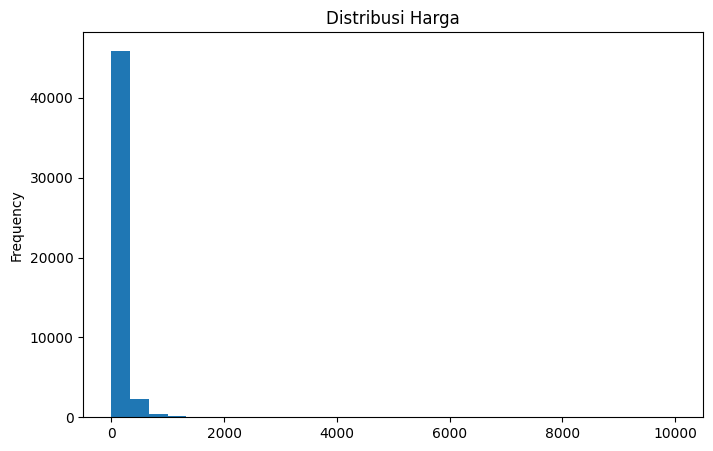

In [44]:
df['price'].plot(kind='hist', bins=30, title='Distribusi Harga', figsize=(8,5))


In [57]:
# Rename kolom (jika perlu)
df.rename(columns={'name': 'listing_name'}, inplace=True)

# Drop kolom
df.drop(columns=['host_id'], inplace=True)

# Sort berdasarkan price
df.sort_values('price', ascending=False).head()


,id,listing_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,total_potential_revenue,price_category
29238,22436899,1-BR Lincoln Center,Manhattan,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,NaN,NaN,1,83,830000,sultan
9151,7003697,Furnished room in Astoria apartment,Queens,Astoria,40.76810,-73.91651,Private room,10000,100,2,2016-02-13,0.04,1,0,0,sultan
17692,13894339,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Greenpoint,40.73260,-73.95739,Entire home/apt,10000,5,5,2017-07-27,0.16,1,0,0,sultan
6530,4737930,Spanish Harlem Apt,Manhattan,East Harlem,40.79264,-73.93898,Entire home/apt,9999,5,1,2015-01-02,0.02,1,0,0,sultan
40433,31340283,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Lower East Side,40.71980,-73.98566,Entire home/apt,9999,30,0,NaN,NaN,1,365,3649635,sultan


## 2. Matplotlib: Plotting, Customization, Subplot, Diagram, Seaborn

### 2.1 Ploting

<ipython-input-46-ff28263602e6>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='neighbourhood_group', palette='Set2')


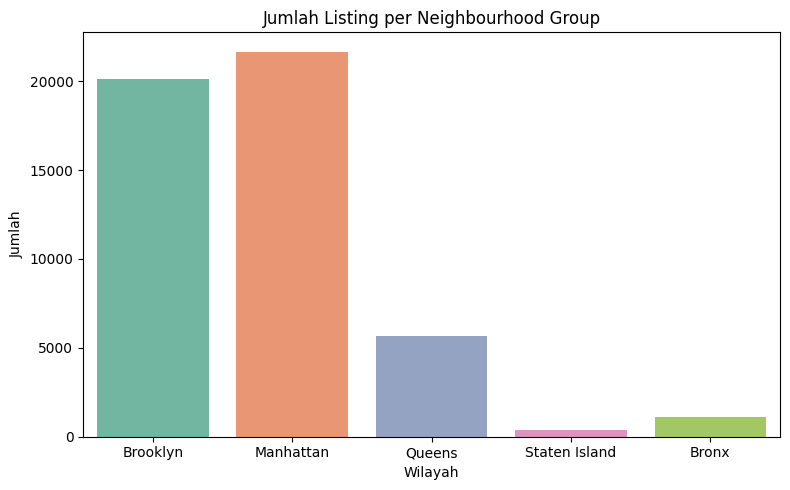

In [46]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='neighbourhood_group', palette='Set2')
plt.title('Jumlah Listing per Neighbourhood Group')
plt.xlabel('Wilayah')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()


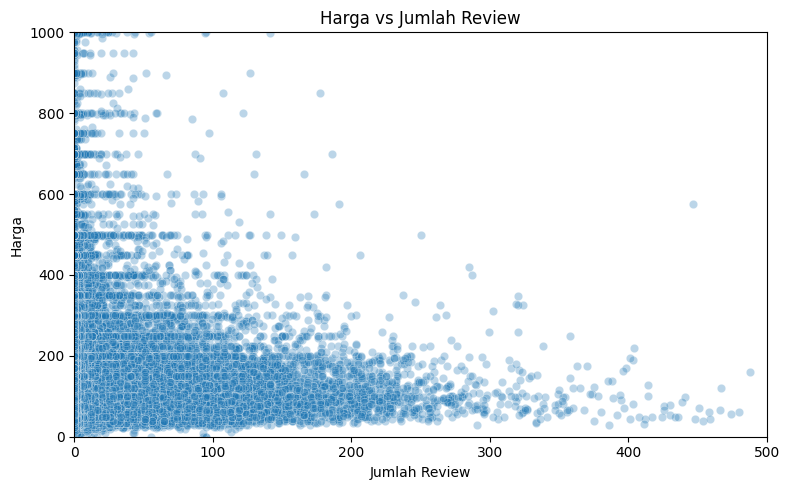

In [47]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='number_of_reviews', y='price', alpha=0.3)
plt.title('Harga vs Jumlah Review')
plt.xlabel('Jumlah Review')
plt.ylabel('Harga')
plt.xlim(0, 500)
plt.ylim(0, 1000)
plt.tight_layout()
plt.show()


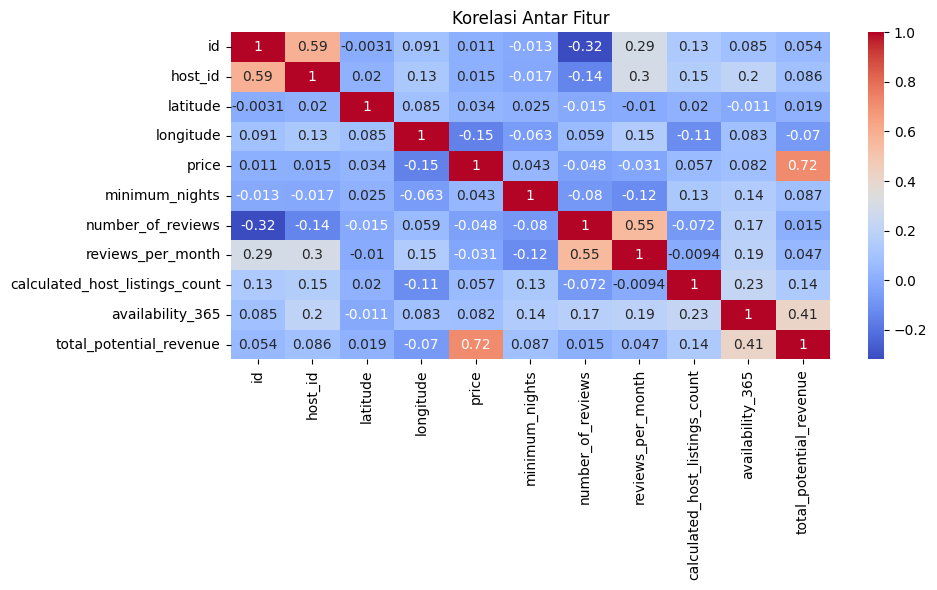

In [48]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Fitur')
plt.tight_layout()
plt.show()


### 2.2 Plot lokasi properti

In [64]:
import folium

# Buat peta pusat di NYC
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Tambah marker listing pertama
folium.Marker(
    [df.iloc[0]['latitude'], df.iloc[0]['longitude']],
    popup=df.iloc[0]['listing_name']
).add_to(nyc_map)

nyc_map


### 2.3 Subplot

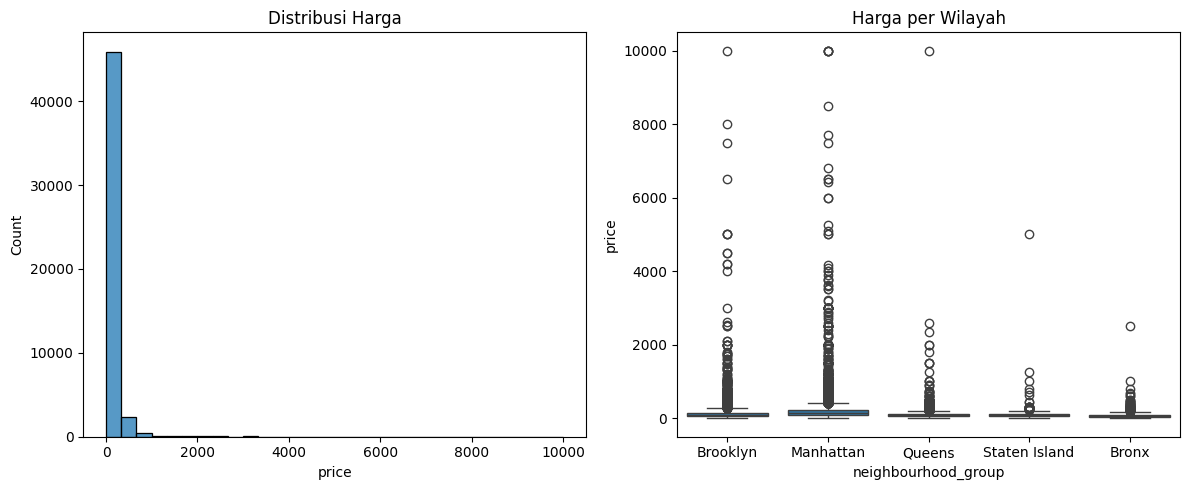

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Histogram harga
sns.histplot(df['price'], ax=axs[0], bins=30)
axs[0].set_title("Distribusi Harga")

# Boxplot harga per wilayah
sns.boxplot(data=df, x='neighbourhood_group', y='price', ax=axs[1])
axs[1].set_title("Harga per Wilayah")

plt.tight_layout()
plt.show()


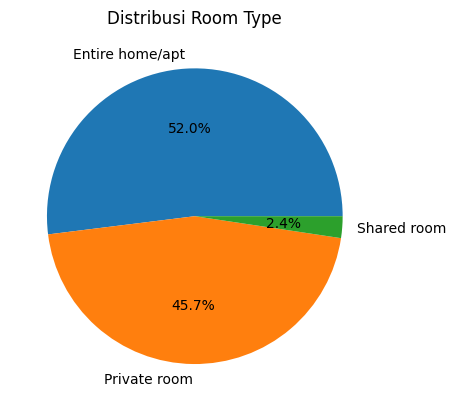

In [50]:
# Pie chart: distribusi jenis room
room_type_counts = df['room_type'].value_counts()
plt.pie(room_type_counts, labels=room_type_counts.index, autopct='%1.1f%%')
plt.title('Distribusi Room Type')
plt.show()


## 3. Data Analysis & Manipulation

In [51]:
df[df['price'] == df['price'].max()]


,id,listing_name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,total_potential_revenue
9151,7003697,Furnished room in Astoria apartment,20582832,Queens,Astoria,40.76810,-73.91651,Private room,10000,100,2,2016-02-13,0.04,1,0,0
17692,13894339,Luxury 1 bedroom apt. -stunning Manhattan views,5143901,Brooklyn,Greenpoint,40.73260,-73.95739,Entire home/apt,10000,5,5,2017-07-27,0.16,1,0,0
29238,22436899,1-BR Lincoln Center,72390391,Manhattan,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,NaN,NaN,1,83,830000


In [52]:
df['neighbourhood'].value_counts().head(10)


,count
neighbourhood,
Williamsburg,3920
Bedford-Stuyvesant,3714
Harlem,2658
Bushwick,2465
Upper West Side,1971
Hell's Kitchen,1958
East Village,1853
Upper East Side,1798
Crown Heights,1564


In [53]:
df.groupby('host_id')['id'].count().sort_values(ascending=False).head(10)


,id
host_id,
219517861,327
107434423,232
30283594,121
137358866,103
12243051,96
16098958,96
61391963,91
22541573,87
200380610,65


In [54]:
# Kategori berdasarkan rentang harga
df['price_category'] = pd.cut(df['price'], bins=[0, 100, 300, 1000, 10000], labels=['murah', 'sedang', 'mahal', 'sultan'])
df['price_category'].value_counts()


,count
price_category,
murah,23917
sedang,21610
mahal,3118
sultan,239
